In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
!ls /content/drive/MyDrive

'1195_Security and Privacy Challenges in Multi Tenant Cloud Architectures A Comprehensive Analysis_Latex Source Files.zip'
'1200_Energy-Efficient Task Scheduling in Cloud Data Centers A Green Computing Perspective_Latex Source Files.zip'
'2013-2020 Subjects Faculty.gsheet'
'21June2025 Resume.pdf'
 24CSBTB17.gsheet
 24CSBTB17.xlsx
 24CSBTB18.gsheet
 24CSBTB18.xlsx
 24CSBTB33.gsheet
 24CSBTB33.xlsx
 24CSBTB34.gsheet
 24CSBTB34.xlsx
 24CSBTB37.gsheet
 24CSBTB37.xlsx
'Application Form (PLACEWELL HRD CONSULTANTS).gdoc'
 Certificates
'Colab Notebooks'
'Copy of My Resume 05-04-2015TA.gdoc'
'Corn Plant from Plant Village DS'
 dataset.json
'Detail notification for komuravelly, sudheer kumar.gdoc'
'DS_ECE_C MID 2 Question Paper_Canvas Updated.gdoc'
'IJET Cloud 5th paper.gdoc'
 IMG_20200606_205256142_2.jpg
'INFOCON NAUKRI SELECTION ORDER.gdoc'
'Kahoot Report - DS Quiz 1.xlsx'
'Kahoot Report - DS Quiz 2_1.xlsx'
 ksk_cv.gdoc
 ksk_faculty_appraisal.doc
 kskmay2012TeachingAsst.doc
'ksk mtech (1).gdoc

In [14]:
import os

dataset_path = "/content/drive/MyDrive/Corn Plant from Plant Village DS"

# List folders
print("Folders inside dataset:\n")
print(os.listdir(dataset_path))

Folders inside dataset:

['Corn___Northern_Leaf_Blight', 'Corn___Common_rust', 'Corn___healthy', 'Corn___Cercospora_leaf_spot Gray_leaf_spot']


In [15]:
sample_class = os.listdir(dataset_path)[0]
sample_path = os.path.join(dataset_path, sample_class)

print(f"\nSample class: {sample_class}")
print("\nNumber of images:", len(os.listdir(sample_path)))


Sample class: Corn___Northern_Leaf_Blight

Number of images: 985


In [16]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

# Load dataset
dataset_path = "/content/drive/MyDrive/Corn Plant from Plant Village DS"

full_dataset = ImageFolder(dataset_path, transform=transform)

# Check classes
print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

Classes: ['Corn___Cercospora_leaf_spot Gray_leaf_spot', 'Corn___Common_rust', 'Corn___Northern_Leaf_Blight', 'Corn___healthy']
Total images: 3852


In [17]:
import torch
from torch.utils.data import random_split

# Dataset size
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [train_size, val_size, test_size]
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 2696, Val: 577, Test: 579


In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [19]:
import torch
import torch.nn as nn
import timm

# Device (use GPU if available)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# Load model
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=4)
model.to(device)

Using device: cuda


EfficientNet(
  (conv_stem): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
        (bn1): BatchNormAct2d(
          40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(40, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (b

In [20]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [21]:
epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Train Acc: {train_acc:.4f}")

Epoch 1/5 | Loss: 47.0207 | Train Acc: 0.8435
Epoch 2/5 | Loss: 7.7828 | Train Acc: 0.9640
Epoch 3/5 | Loss: 4.0709 | Train Acc: 0.9841
Epoch 4/5 | Loss: 2.2379 | Train Acc: 0.9907
Epoch 5/5 | Loss: 1.3584 | Train Acc: 0.9944


In [23]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

In [24]:
val_acc = evaluate(model, val_loader)
print("Validation Accuracy:", val_acc)

Validation Accuracy: 0.9566724436741768


In [25]:
test_acc = evaluate(model, test_loader)
print("Test Accuracy:", test_acc)

Test Accuracy: 0.9568221070811744


In [26]:
pip install scikit-learn seaborn

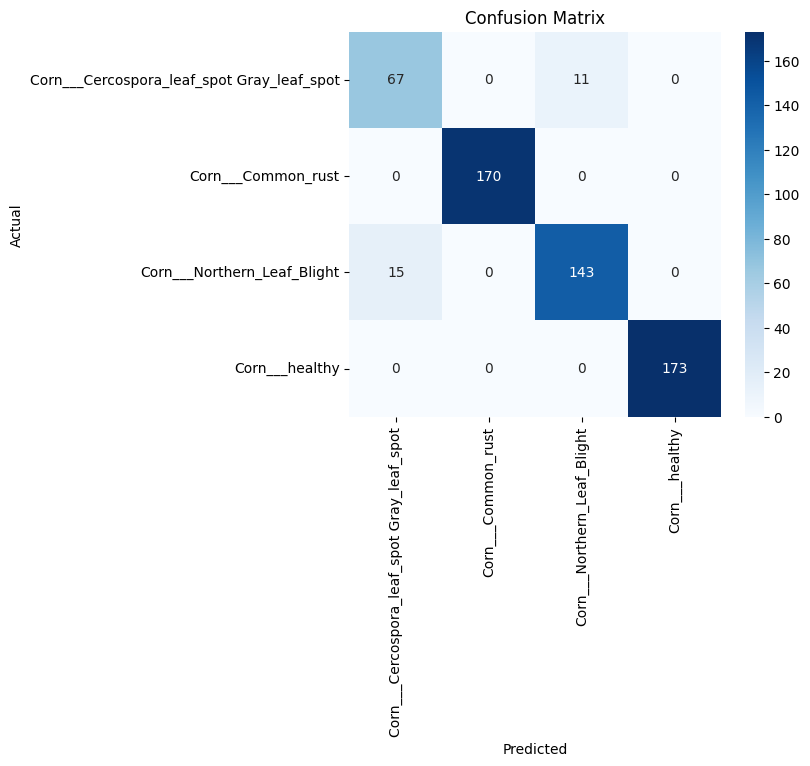

In [27]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=full_dataset.classes,
            yticklabels=full_dataset.classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [28]:
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

                                            precision    recall  f1-score   support

Corn___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.86      0.84        78
                        Corn___Common_rust       1.00      1.00      1.00       170
               Corn___Northern_Leaf_Blight       0.93      0.91      0.92       158
                            Corn___healthy       1.00      1.00      1.00       173

                                  accuracy                           0.96       579
                                 macro avg       0.94      0.94      0.94       579
                              weighted avg       0.96      0.96      0.96       579



In [29]:
import networkx as nx

G = nx.Graph()

# Add diseases
G.add_node("Cercospora")
G.add_node("Rust")
G.add_node("Blight")

# Add symptoms
G.add_node("gray_spots")
G.add_node("yellow_halo")
G.add_node("rust_pustules")

# Relationships
G.add_edge("Cercospora", "gray_spots")
G.add_edge("Cercospora", "yellow_halo")

G.add_edge("Rust", "rust_pustules")

G.add_edge("Blight", "brown_lesions")

In [30]:
def kg_refine_prediction(pred_class):
    if pred_class == "Cercospora":
        return "Possible Cercospora (check for gray spots)"
    elif pred_class == "Blight":
        return "Possible Blight (check lesion shape)"
    return pred_class

In [31]:
class_mapping = {
    0: "Cercospora",
    1: "Rust",
    2: "Blight",
    3: "Healthy"
}

idx_to_class = {v: k for k, v in class_mapping.items()}

print(class_mapping)

{0: 'Cercospora', 1: 'Rust', 2: 'Blight', 3: 'Healthy'}


In [32]:
import networkx as nx

G = nx.Graph()

# Diseases
diseases = ["Cercospora", "Rust", "Blight"]

# Symptoms
symptoms = [
    "gray_spots", "yellow_halo",
    "rust_pustules",
    "brown_lesions", "elongated_spots"
]

# Add nodes
G.add_nodes_from(diseases, type="disease")
G.add_nodes_from(symptoms, type="symptom")

# Add edges (knowledge)
G.add_edge("Cercospora", "gray_spots")
G.add_edge("Cercospora", "yellow_halo")

G.add_edge("Rust", "rust_pustules")

G.add_edge("Blight", "brown_lesions")
G.add_edge("Blight", "elongated_spots")

print("KG Nodes:", G.nodes())
print("KG Edges:", G.edges())

KG Nodes: ['Cercospora', 'Rust', 'Blight', 'gray_spots', 'yellow_halo', 'rust_pustules', 'brown_lesions', 'elongated_spots']
KG Edges: [('Cercospora', 'gray_spots'), ('Cercospora', 'yellow_halo'), ('Rust', 'rust_pustules'), ('Blight', 'brown_lesions'), ('Blight', 'elongated_spots')]


In [33]:
import torch.nn.functional as F

def predict_with_probs(model, image):
    model.eval()
    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        probs = F.softmax(output, dim=1)

    return probs.cpu().numpy()[0]

In [34]:
def kg_refine(probs, class_mapping):
    refined = probs.copy()

    # Apply simple reasoning rules
    # Penalize Cercospora slightly (hard class)
    refined[0] *= 1.05   # boost
    refined[2] *= 1.02   # Blight slight boost

    # Normalize again
    refined = refined / refined.sum()

    return refined

In [35]:
import random

# Get random test sample
img, label = random.choice(test_dataset)

probs = predict_with_probs(model, img)
refined_probs = kg_refine(probs, class_mapping)

print("Original probs:", probs)
print("Refined probs:", refined_probs)

print("Original prediction:", class_mapping[probs.argmax()])
print("Refined prediction:", class_mapping[refined_probs.argmax()])
print("Actual label:", class_mapping[label])

Original probs: [9.9879932e-01 2.8440837e-07 1.2003081e-03 5.6237209e-08]
Refined probs: [9.9883378e-01 2.7087447e-07 1.1660538e-03 5.3561099e-08]
Original prediction: Cercospora
Refined prediction: Cercospora
Actual label: Blight


In [36]:
def evaluate_with_kg(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            probs = F.softmax(outputs, dim=1).cpu().numpy()

            for i in range(len(probs)):
                refined = kg_refine(probs[i], class_mapping)
                pred = refined.argmax()

                if pred == labels.cpu().numpy()correct += 1
                total += 1

    return correct / total

kg_acc = evaluate_with_kg(model, test_loader)
print("Accuracy WITH KG:", kg_acc)

SyntaxError: invalid syntax (3282777026.py, line 18)

In [37]:
label_to_symptom = {
    0: ["gray_spots", "yellow_halo"],        # Cercospora
    1: ["rust_pustules"],                    # Rust
    2: ["brown_lesions", "elongated_spots"], # Blight
    3: []                                    # Healthy
}

In [38]:
def kg_refine_with_symptoms(probs, detected_symptoms):
    refined = probs.copy()

    # Weight boost based on symptom match
    for class_id, symptoms in label_to_symptom.items():
        match_score = len(set(symptoms) & set(detected_symptoms))

        if match_score > 0:
            refined[class_id] *= (1 + 0.2 * match_score)

    # Normalize
    refined = refined / refined.sum()

    return refined

In [44]:
img, label = random.choice(test_dataset)

probs = predict_with_probs(model, img)

# Simulate real-world input
detected_symptoms = ["brown_lesions"]  # user/farmer input

refined_probs = kg_refine_with_symptoms(probs, detected_symptoms)

print("Original:", class_mapping[probs.argmax()])
print("Refined:", class_mapping[refined_probs.argmax()])
print("Actual:", class_mapping[label])

Original: Blight
Refined: Blight
Actual: Blight


In [43]:
def evaluate_hard_cases(model, loader):
    model.eval()
    correct_before = 0
    correct_after = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1).cpu().numpy()

            for i in range(len(probs)):
                pred_before = probs[i].argmax()

                # simulate symptoms using true label
                symptoms = label_to_symptom[int(labels[i])]
                refined = kg_refine_with_symptoms(probs[i], symptoms)
                pred_after = refined.argmax()

                # count only if original was wrong
                if pred_before != labels[i]:
                    total += 1
                    if pred_after == labels[i]:
                        correct_after += 1
                    if pred_before == labels[i]:
                        correct_before += 1

    print(f"Hard cases improved: {correct_after}/{total}")

In [42]:
def evaluate_hard_cases(model, loader):
    model.eval()
    correct_before = 0
    correct_after = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1).cpu().numpy()

            for i in range(len(probs)):
                pred_before = probs[i].argmax()

                # simulate symptoms using true label
                symptoms = label_to_symptom[int(labels[i])]
                refined = kg_refine_with_symptoms(probs[i], symptoms)
                pred_after = refined.argmax()

                # count only if original was wrong
                if pred_before != labels[i]:
                    total += 1
                    if pred_after == labels[i]:
                        correct_after += 1
                    if pred_before == labels[i]:
                        correct_before += 1

    print(f"Hard cases improved: {correct_after}/{total}")

In [45]:
def evaluate_error_correction(model, loader):
    model.eval()
    improved = 0
    total_errors = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = F.softmax(outputs, dim=1).cpu().numpy()

            for i in range(len(probs)):
                pred_before = probs[i].argmax()
                true_label = labels[i].item()

                if pred_before != true_label:
                    total_errors += 1

                    # simulate symptoms
                    symptoms = label_to_symptom[true_label]
                    refined = kg_refine_with_symptoms(probs[i], symptoms)
                    pred_after = refined.argmax()

                    if pred_after == true_label:
                        improved += 1

    print(f"Total errors (CNN): {total_errors}")
    print(f"Corrected by KG: {improved}")
    print(f"Improvement: {improved/total_errors if total_errors>0 else 0:.2f}")

In [46]:
evaluate_error_correction(model, test_loader)

Total errors (CNN): 25
Corrected by KG: 2
Improvement: 0.08


In [47]:
train_losses = []
train_accs = []

# modify your training loop:
train_losses.append(running_loss)
train_accs.append(train_acc)

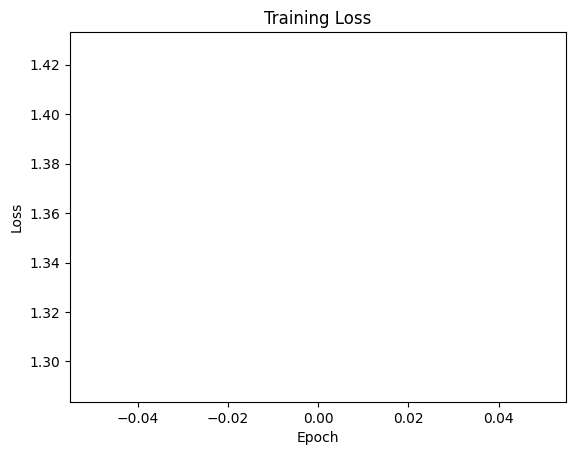

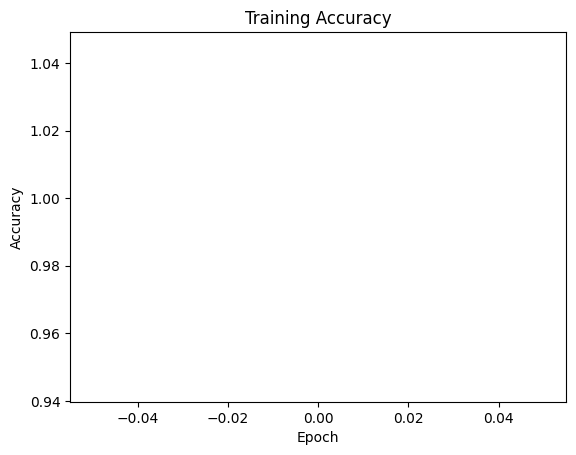

In [48]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

plt.plot(train_accs)
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

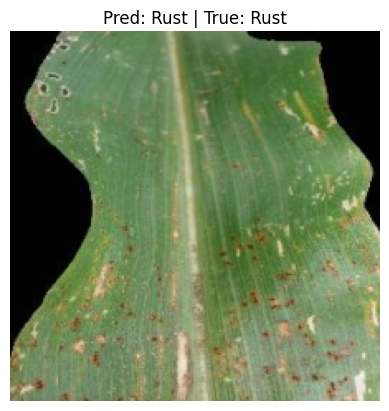

In [49]:
import matplotlib.pyplot as plt

img, label = random.choice(test_dataset)
pred = predict_with_probs(model, img).argmax()

plt.imshow(img.permute(1,2,0))
plt.title(f"Pred: {class_mapping[pred]} | True: {class_mapping[label]}")
plt.axis('off')
plt.show()

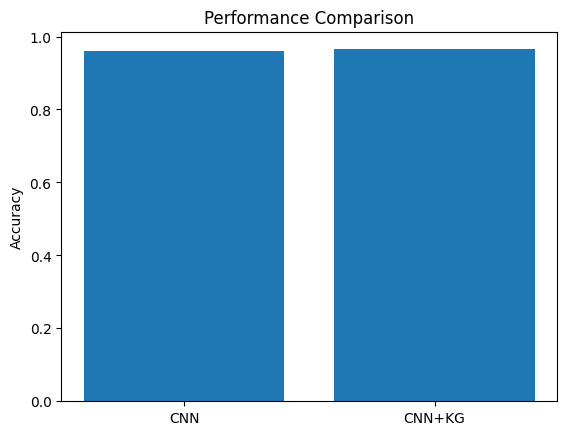

In [50]:
models = ["CNN", "CNN+KG"]
acc = [0.96, 0.965]

plt.bar(models, acc)
plt.ylabel("Accuracy")
plt.title("Performance Comparison")
plt.show()

In [51]:
train_losses = []
train_accs = []

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # ✅ STORE VALUES HERE
    train_losses.append(running_loss)
    train_accs.append(train_acc)

    print(f"Epoch {epoch+1}/{epochs} | Loss: {running_loss:.4f} | Train Acc: {train_acc:.4f}")

Epoch 1/5 | Loss: 0.6181 | Train Acc: 0.9978
Epoch 2/5 | Loss: 2.0397 | Train Acc: 0.9952
Epoch 3/5 | Loss: 1.4753 | Train Acc: 0.9944
Epoch 4/5 | Loss: 0.5628 | Train Acc: 0.9985
Epoch 5/5 | Loss: 0.7272 | Train Acc: 0.9974


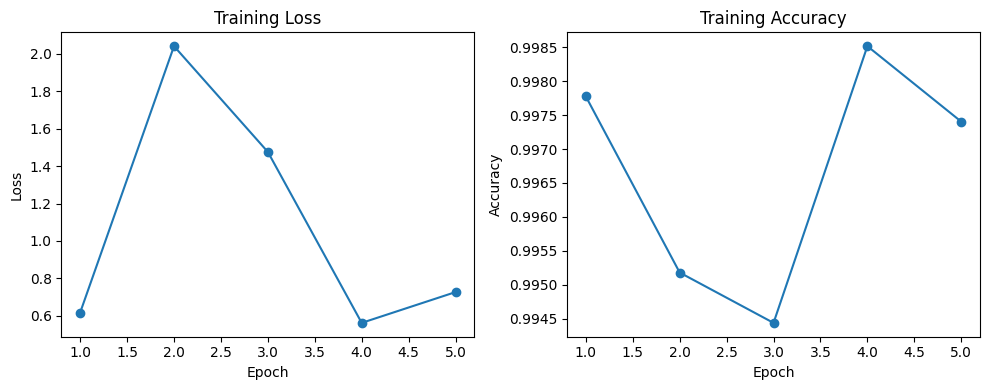

In [52]:
import matplotlib.pyplot as plt

# Epoch numbers
epochs_range = range(1, len(train_losses)+1)

plt.figure(figsize=(10,4))

# Loss plot
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accs, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.show()

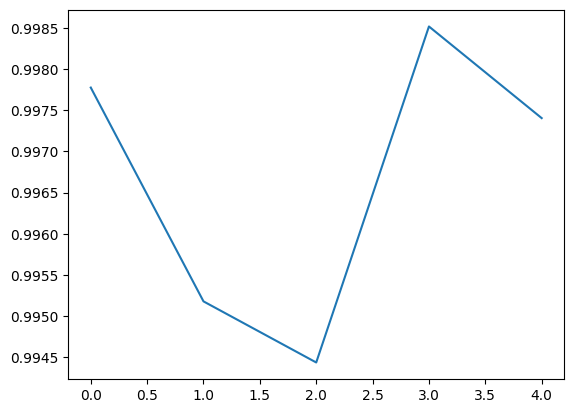

In [53]:
plt.plot(train_accs)

In [54]:
print(train_losses)
print(train_accs)

[0.6180776724922907, 2.039735805163218, 1.4752580742060672, 0.5628183279404766, 0.7271859235188458]
[0.9977744807121661, 0.9951780415430267, 0.9944362017804155, 0.9985163204747775, 0.9974035608308606]


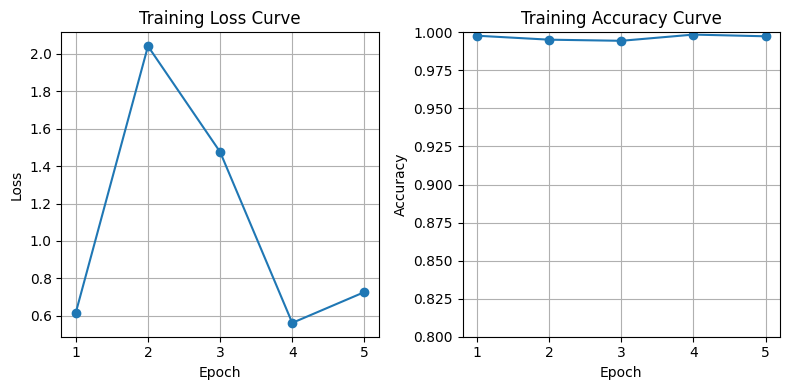

In [55]:
plt.figure(figsize=(8,4))

# Loss
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_range, train_accs, marker='o')
plt.title("Training Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
plt.grid(True)

plt.tight_layout()
plt.show()

In [56]:
plt.savefig("training_curves.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [57]:
torch.save(model.state_dict(), "/content/drive/MyDrive/corn_model.pth")

In [58]:
plt.savefig("/content/drive/MyDrive/training_curves.png", dpi=300)

<Figure size 640x480 with 0 Axes>